# Trabalho 2 de ARQ - G13

---
<h1>Atividade 02 - melhorar o desempenho de RP em conjunto de dados existentes</h1>
<p>A atividade 02 visa trabalhar com um conjunto de dados pré-construído, onde as opções que o desenvolvedor tem, são de aplicar as técnicas de pré-processamento abaixo relacionadas:</p>
<ul><li>Seleção</li>
<li>Limpeza</li>
<li>Codificação</li>
<li>Enriquecimento</li>
<li>Normalização</li>
<li>Construção de Atributos</li>
<li>Correção de Prevalência</li>
<li>Partição do Conjunto de Dados</li>
</ul>
<p>Busque uma base de dados na UCI Machine Learning que seja indicada para problemas de classificação. (<a target="_blank" href="https://archive.ics.uci.edu/datasets">https://archive.ics.uci.edu/datasets</a>)</p>



<p>Nossa opção foi pela base "Adult Census Income", cujo objetivo é predizer se o valor de income é maior que 50k</p>
<p>O Dataset "Adult" da UCI, também conhecido como "Census Income Dataset", é largamente utilizado para tarefas de classificação para predizer se a soma de valores recebidos anualmente superam $50,000.00 baseado nos atributos demográficos e de emprego. Ele possui 14 atributos (features), tanto categóricas como numéricas, e requer pré-processamento e seleção de atributos para otimizar o desempenho do modelo.</p>
<p>O Dataset possui os seguinte atributos:</p>

- Numéricos: age, fnlwgt, education-num, capital-gain, capital-loss e hours-per-week 
   
- Categóricos: workclass, education, marital-status, occupation, relationship, race, sex e native-country

<p>A variável target é income, que pode assumir dois valores: '<=50K' ou '>50K'.</p>

---
## Baseline de Acurácia

<p><b>Linha de base (baseline) do dataset Adult sem tratamento:</b> ~76%</p>
<p>Este é o valor obtido por um modelo que simplesmente prevê a classe majoritária (&lt;=50K) 
para todas as amostras — um "chute" ingênuo que já acerta 76% devido ao desbalanceamento natural dos dados 
(~75% ganham &lt;=50K, ~25% ganham &gt;50K).</p>

<p><b>Referências da comunidade e literatura:</b></p>
<ul>
<li>UCI Machine Learning Repository — Adult Dataset: 
<a target="_blank" href="https://archive.ics.uci.edu/dataset/2/adult">https://archive.ics.uci.edu/dataset/2/adult</a></li>
</ul>

<p><b>Comparativo das acurácias obtidas neste notebook:</b></p>
<table>
<tr><th>Modelo</th><th>Acurácia (teste)</th><th>Ganho sobre baseline</th></tr>
<tr><td>Baseline ingênuo (sempre &lt;=50K)</td><td>~76%</td><td>—</td></tr>
<tr><td>SVM sem padronização</td><td>80%</td><td>+4 p.p.</td></tr>
<tr><td>SVM com padronização</td><td>85%</td><td>+9 p.p.</td></tr>
<tr><td><b>XGBoost</b></td><td><b>87%</b></td><td><b>+11 p.p.</b></td></tr>
</table>

<p><b>Critério de avaliação:</b> Considerando que a acurácia original está abaixo do critério de até 85% (~76%), a meta era obter uma melhora de <b>5 pontos percentuais</b>. O melhor modelo (XGBoost) obteve <b>87%</b>, um ganho de <b>+11 p.p.</b> sobre o baseline, superando amplamente a meta estabelecida.</p>

---
## 1. Parâmetros globais e carregamento das bibliotecas

In [34]:
# Hyperparametros
RAND_STATE = 13 # em homenagem ao Grupo!!
TEST_SIZE = 0.2 # 20% do Dataset para teste
FIG_SIZE = (8,5) # Tamanho das figuras

In [35]:
#  Bibliotecas básicas
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas para o modelo e avaliação
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import svm

# Configuração de exibição
sns.set_style("darkgrid")


---
## 2. Carregamento do Dataset

In [36]:
# << MUDANÇA: CÉLULA REESTRUTURADA
# se adult.zip existir localmente, carrega do zip
# caso contrário, baixa da internet via ucimlrepo.


import os
import zipfile

colunas = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

if os.path.exists("adult.zip"):
    # ------------------------------------------------------------
    # 1. Carrega do arquivo local (adult.zip)
    # ------------------------------------------------------------
    print("Usando cópia local")

    with zipfile.ZipFile("adult.zip") as z:
        with z.open("adult.data") as f:
            train = pd.read_csv(
                f,
                header=None,
                names=colunas,
                na_values="?",
                skipinitialspace=True
            )
        with z.open("adult.test") as f:
            test = pd.read_csv(
                f,
                header=None,
                names=colunas,
                na_values="?",
                skipinitialspace=True
            )
    df = pd.concat([train, test], axis=0, ignore_index=False)

    # remove ponto final da coluna income (bug do dataset)
    df["income"] = df["income"].str.replace('.', '', regex=False)

else:
    # ------------------------------------------------------------
    # 2. Baixa da internet via ucimlrepo
    # ------------------------------------------------------------
    print("adult.zip não encontrado. Baixando da UCI repository...")

    try:
        from ucimlrepo import fetch_ucirepo
    except ImportError:
        %pip install ucimlrepo
        from ucimlrepo import fetch_ucirepo

    adult = fetch_ucirepo(id=2)  # https://archive.ics.uci.edu/dataset/2/adult

    df = pd.concat(
        [adult.data.features, adult.data.targets],
        axis=1,
        ignore_index=False
    )

    # remove ponto final da coluna income (bug do dataset)
    df["income"] = df["income"].str.replace('.', '', regex=False)

    # Converte '?' em NaN
    df = df.replace("?", np.nan)

    print("Dataset baixado com sucesso!")
    display(adult.variables)

# ------------------------------------------------------------
# Garantir que 'age' seja tratada como número
# ------------------------------------------------------------
df["age"] = pd.to_numeric(df["age"], errors="coerce").astype("Int64")

print(f"\nDataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas")

Usando cópia local

Dataset carregado: 48843 linhas x 15 colunas


---
## 3. Resumo dos dados

In [37]:
print("Shape:", df.shape)
df.info()
df.describe().style.background_gradient(cmap='Reds')

Shape: (48843, 15)
<class 'pandas.DataFrame'>
Index: 48843 entries, 0 to 16281
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48842 non-null  Int64  
 1   workclass       46043 non-null  str    
 2   fnlwgt          48842 non-null  float64
 3   education       48842 non-null  str    
 4   education-num   48842 non-null  float64
 5   marital-status  48842 non-null  str    
 6   occupation      46033 non-null  str    
 7   relationship    48842 non-null  str    
 8   race            48842 non-null  str    
 9   sex             48842 non-null  str    
 10  capital-gain    48842 non-null  float64
 11  capital-loss    48842 non-null  float64
 12  hours-per-week  48842 non-null  float64
 13  native-country  47985 non-null  str    
 14  income          48842 non-null  str    
dtypes: Int64(1), float64(5), str(9)
memory usage: 6.0 MB


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,189664.134597,10.078089,1079.067626,87.502314,40.422382
std,13.710510,105604.025423,2.570973,7452.019058,403.004552,12.391444
min,17.000000,12285.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,117550.500000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,178144.500000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,237642.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,1490400.000000,16.000000,99999.000000,4356.000000,99.000000


---
## 4. Limpeza dos dados

In [38]:
print(f'\nDimensões do Dataset: {df.shape[0]} linhas x {df.shape[1]} colunas\n')


Dimensões do Dataset: 48843 linhas x 15 colunas



In [39]:
print("=== Valores faltantes por coluna ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valores Faltantes': missing, 'Percentual (%)': missing_pct})
print(missing_df[missing_df['Valores Faltantes'] > 0])

=== Valores faltantes por coluna ===
                Valores Faltantes  Percentual (%)
age                             1            0.00
workclass                    2800            5.73
fnlwgt                          1            0.00
education                       1            0.00
education-num                   1            0.00
marital-status                  1            0.00
occupation                   2810            5.75
relationship                    1            0.00
race                            1            0.00
sex                             1            0.00
capital-gain                    1            0.00
capital-loss                    1            0.00
hours-per-week                  1            0.00
native-country                858            1.76
income                          1            0.00


In [40]:
# Verifica se existe linhas duplicadas
print(f'=== Verificação de Dados Duplicados ===')

duplicadas = df.duplicated().sum()
print(f'Total de linhas duplicadas: {duplicadas:,}')

# remoção de linhas duplicadas
if duplicadas > 0:
  print("\nIndice das linhas duplicadas:")
  print(df[df.duplicated(keep=False)].index.values)
  df = df.drop_duplicates()
  print(f'\nLinhas após remoção de duplicatas: {len(df):}')
else:
  print('\nNenhuma linha duplicata encontrada. Nenhuma ação necessária.')

=== Verificação de Dados Duplicados ===
Total de linhas duplicadas: 52

Indice das linhas duplicadas:
[ 2195  2303  3118  3445  3917  4325  4767  4881  4940  5104  5579  5805
  5842  6990  7053  7920  8080  8679  8908  9171  9371  9841 10094 10367
 11631 11965 13084 14581 14690 15059 15189 16297 16846 16975 17040 17673
 17867 17916 18555 18698 19567 20486 20567 21103 21318 21490 21875 21974
 22249 22300 22367 22494 24667 25624 25684 25872 26313 27920 28230 28522
 28846 29157 30345 30384 30698 30845 31993 32404   489   865  1320  1669
  1855  1864  3901  4153  5079  5783  5908  6433  6457  7022  7351  8117
  9250  9826 10827 10924 11190 11213 11747 12489 13505 13849 14154 14309
 14399 14488 14839 15324 15961]

Linhas após remoção de duplicatas: 48791


In [41]:
# << MUDANÇA: CELULA COMENTADA
#
# Antes: preenchia valores faltantes no df INTEIRO (vazamento de dados).
# Agora: separa treino/teste ANTES de preencher, usando estatísticas
# apenas do conjunto de treino para ambos os conjuntos.
#

# # Substitui valores faltantes pela moda ou média
# for col in df.columns:
#     if is_numeric_dtype(df[col]):
#         df[col] = df[col].fillna(df[col].median())
#     else:
#         df[col] = df[col].fillna(df[col].mode()[0])



In [42]:
# << MUDANÇA: NOVA CELULA
# Remove as linhas com NaN na coluna TARGET (income) — necessário para o stratify
qtd_antes = df.shape[0]
df = df.dropna(subset=['income'])
qtd_removidas = qtd_antes - df.shape[0]
print(f'Linhas removidas com NaN em income: {qtd_removidas}')

Linhas removidas com NaN em income: 1


---
## 5. Separação de Features e Target

In [43]:
# << MUDANÇA: Separa features & target (NaN serão tratados na célula 22)

# Separar features & target
X = df.drop("income", axis=1)

# Converte target em binário
y = df["income"].copy()

# Identifica features numéricas e categóricas
# Vai ser usado no EDA
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["string", "object"]).columns.tolist()

---
## 6. Divisão em Treino e Teste

In [44]:
# << MUDANÇA: NOVA CELULA

# Train/test split - mantém a proporção das classes (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RAND_STATE, stratify=y)


---
## 7. Imputação de Dados

In [45]:
# << MUDANÇA: NOVA CELULA
# VAZAMENTO DE DADOS CORRIGIDO
# Realiza a imputação de valores faltantes APÓS o split,
#  usando apenas estatísticas do conjunto de treino para evitar vazamento de dados.
# (O NaN do target já foi removido na célula anterior.)

# --- Imputação das features ---
# Preenche valores faltantes no TREINO com mediana/moda do TREINO
for col in X_train.columns:
    if is_numeric_dtype(X_train[col]):
        X_train[col] = X_train[col].fillna(X_train[col].median())
    else:
        X_train[col] = X_train[col].fillna(X_train[col].mode()[0])

# Preenche valores faltantes no TESTE com mediana/moda do TREINO (evita vazamento!)
for col in X_test.columns:
    if is_numeric_dtype(X_test[col]):
        X_test[col] = X_test[col].fillna(X_train[col].median())  # mediana do TREINO
    else:
        X_test[col] = X_test[col].fillna(X_train[col].mode()[0])  # moda do TREINO

In [46]:
# << MUDANÇA: CÉLULA MANTIDA PARA EDA

# Cria DataFrame combinado de treino para EDA usando apenas X_train e y_train
df_train = X_train.copy()
df_train["income"] = y_train

---
## 8. Análise exploratória de dados

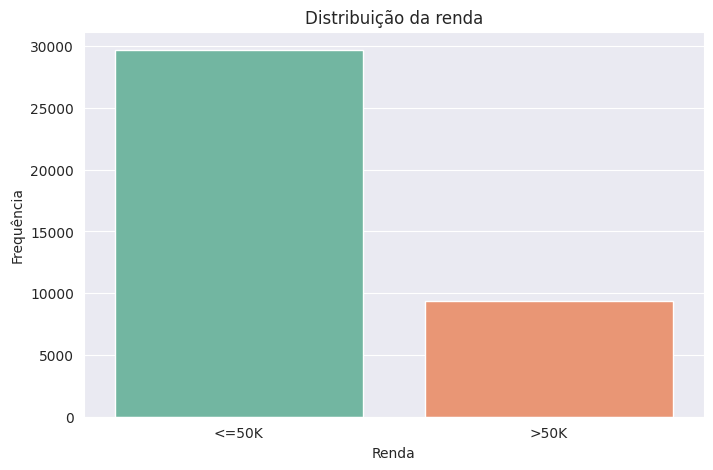

In [47]:
# MUDANÇA: BLOCO DE COMENTÁRIOS ADICIONADO
# Prevalência de leve a moderada confirmada (uso do stratify no train_test_split).

plt.figure(figsize=FIG_SIZE)
sns.countplot(data=df_train, x="income", hue="income", palette="Set2")
plt.title("Distribuição da renda")
plt.xlabel("Renda")
plt.ylabel("Frequência")
plt.show()

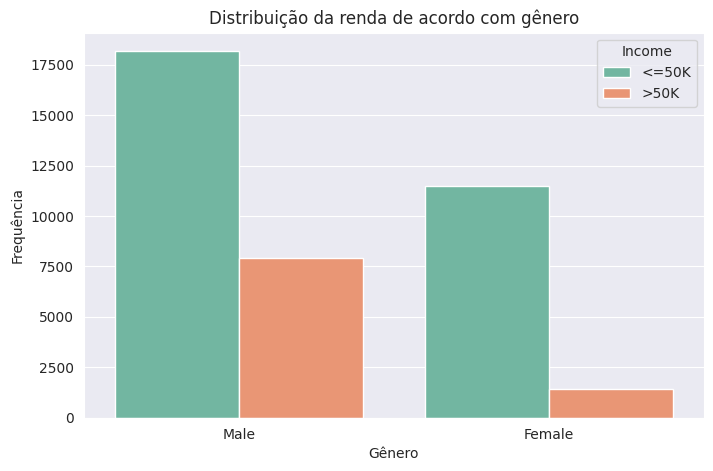

In [48]:
plt.figure(figsize=FIG_SIZE)
sns.countplot(data=df_train, x="sex", hue="income", palette="Set2")
plt.title("Distribuição da renda de acordo com gênero")
plt.xlabel("Gênero")
plt.ylabel("Frequência")
plt.legend(title="Income")
plt.show()

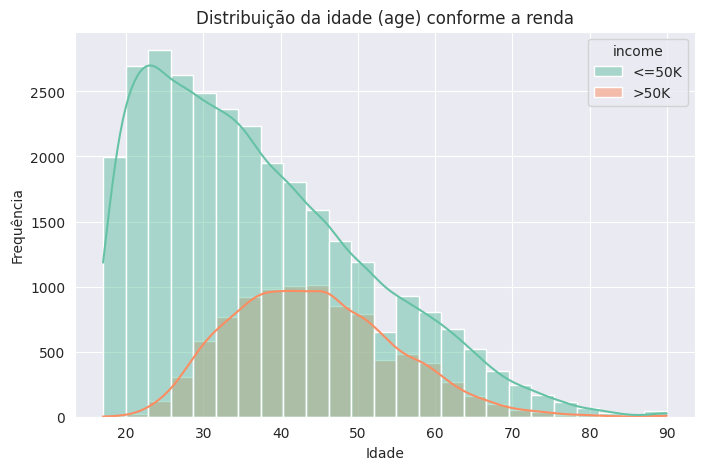

In [49]:
plt.figure(figsize=FIG_SIZE)
sns.histplot(data=df_train, x="age", hue="income", bins=25, palette="Set2", kde=True)
plt.title("Distribuição da idade (age) conforme a renda")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

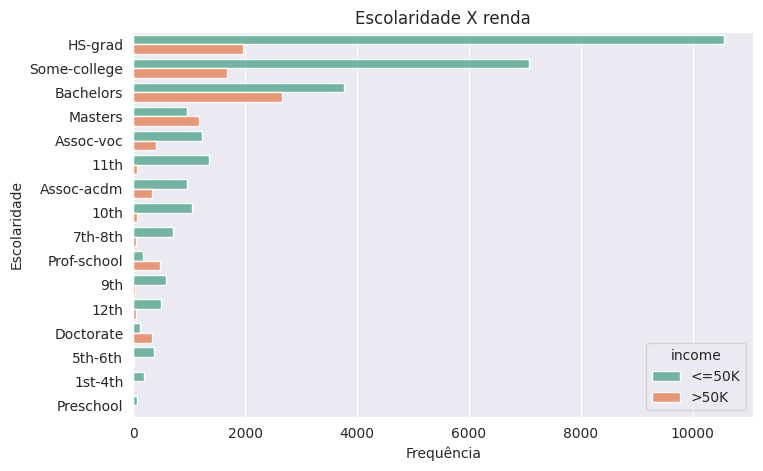

In [50]:
plt.figure(figsize=FIG_SIZE)
order = df_train["education"].value_counts().index
sns.countplot(data=df_train, y="education", order=order, hue="income", palette="Set2")
plt.title("Escolaridade X renda")
plt.xlabel("Frequência")
plt.ylabel("Escolaridade")
plt.show()

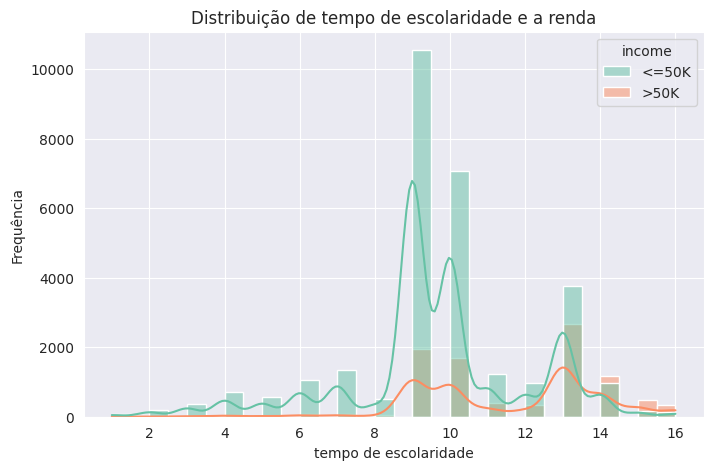

In [51]:
plt.figure(figsize=FIG_SIZE)
sns.histplot(
    data=df_train,
    x="education-num",
    hue="income",
    bins=30,
    kde=True,
    palette="Set2"
)

plt.title("Distribuição de tempo de escolaridade e a renda")
plt.xlabel("tempo de escolaridade")
plt.ylabel("Frequência")
plt.show()

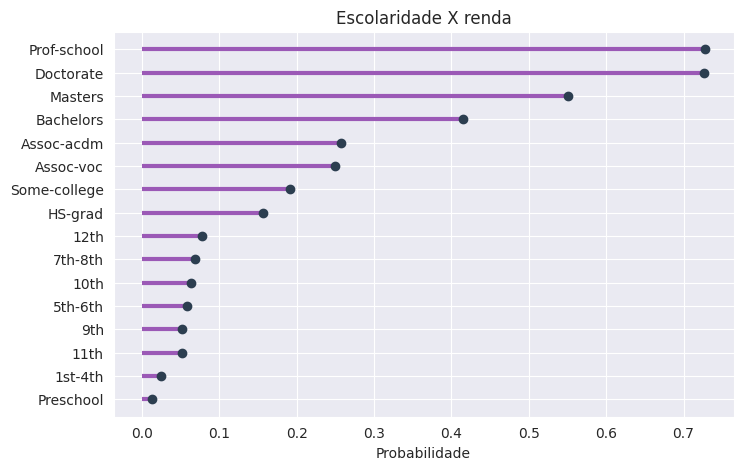

In [52]:
edu_income = (
    df_train.groupby("education")["income"]
    .apply(lambda x: (x == ">50K").mean())
    .sort_values()
)

plt.figure(figsize=FIG_SIZE)
plt.hlines(
    y=edu_income.index,
    xmin=0,
    xmax=edu_income.values,
    color="#9b59b6",
    linewidth=3
)
plt.plot(
    edu_income.values,
    edu_income.index,
    "o",
    color="#2c3e50"
)

plt.title("Escolaridade X renda")
plt.xlabel("Probabilidade")
plt.show()

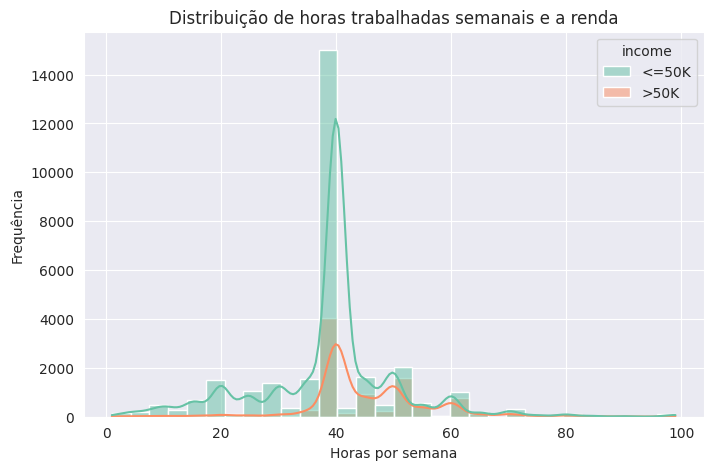

In [53]:
plt.figure(figsize=FIG_SIZE)
sns.histplot(
    data=df_train,
    x="hours-per-week",
    hue="income",
    bins=30,
    kde=True,
    palette="Set2"
)

plt.title("Distribuição de horas trabalhadas semanais e a renda")
plt.xlabel("Horas por semana")
plt.ylabel("Frequência")
plt.show()

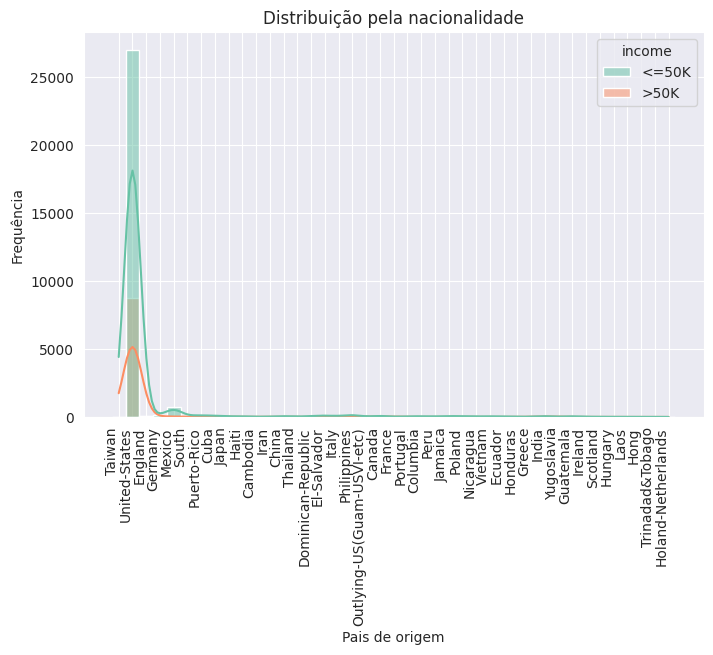

In [54]:
plt.figure(figsize=FIG_SIZE)
sns.histplot(
    data=df_train,
    x="native-country",
    hue="income",
    bins=30,
    kde=True,
    palette="Set2"
)

plt.title("Distribuição pela nacionalidade")
plt.xticks(rotation=90, ha='right')
plt.xlabel("Pais de origem")
plt.ylabel("Frequência")
plt.show()

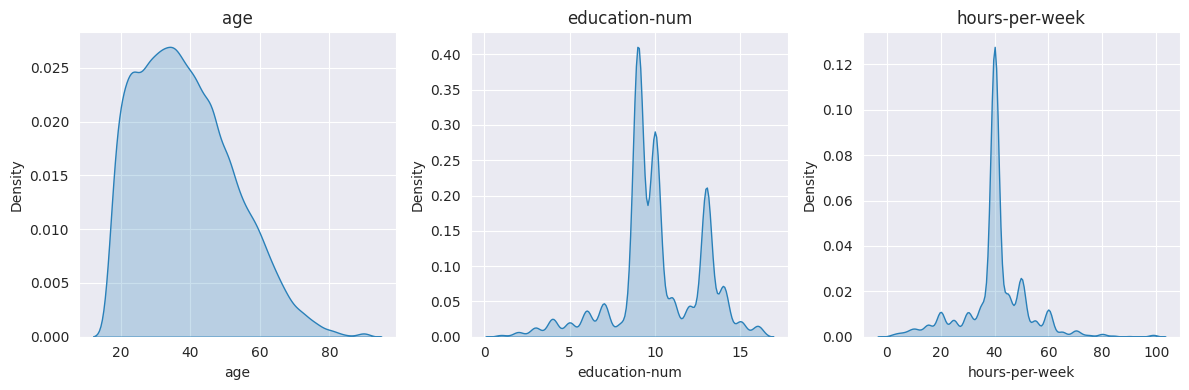

In [55]:
# Verifica a distribuição de algumas features numéricas
num_features = ["age", "education-num", "hours-per-week"]

plt.figure(figsize=(12,4))
for i, col in enumerate(num_features, 1):
    plt.subplot(1,3,i)
    sns.kdeplot(df_train[col], fill=True, color="#2980b9")
    plt.title(col)

plt.tight_layout()
plt.show()

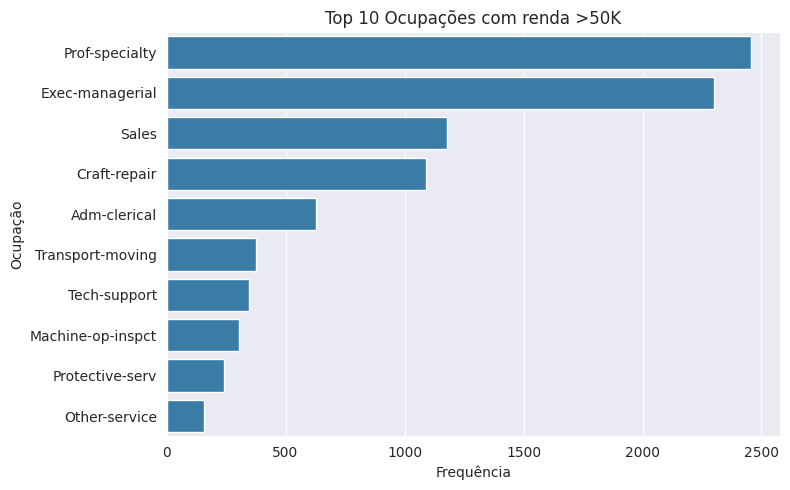

In [56]:
# Filtrar income >50K
df_high_income = df_train[df_train['income'] == '>50K']

# Contar occupations
top_occupations = (
    df_high_income['occupation']
    .value_counts()
    .head(10)
)

# Plot
plt.figure(figsize=FIG_SIZE)

sns.barplot(
    x=top_occupations.values,
    y=top_occupations.index,
    color="#2980b9"
)

plt.title("Top 10 Ocupações com renda >50K")
plt.xlabel("Frequência")
plt.ylabel("Ocupação")

plt.tight_layout()
plt.show()

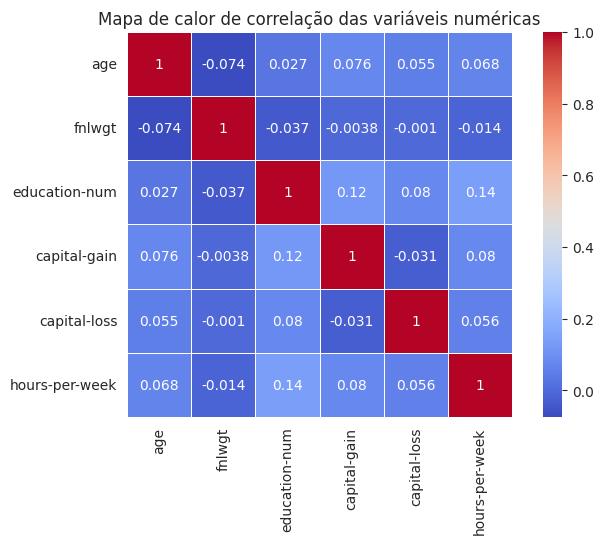

In [57]:
# << MUDANÇA: BLOCO DE COMENTÁRIOS ADICIONADO
# Análise de Multicolinearidade (excesso de informação repetida), dois atributos por vez.
#
# Aqui a variável dependente (income) é ignorada

# num_cols específico de df_train
num_cols = df_train.select_dtypes(include="number").columns.tolist()

corr = df_train[num_cols].corr()

plt.figure(figsize=FIG_SIZE)
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Mapa de calor de correlação das variáveis numéricas")
plt.show()

# Todas as correlações pareadas são muito baixas

---
## 9. Redução de dimensionalidade


In [58]:
# << MUDANÇA: CÉLULA ALTERADA

# Remover fnlwpt por conhecimento de domínio. É uma variável 
# que não deveria estar no dataset para predição
# 
# Não descreve a pessoa, indica apenas quantas pessoas da população
#  cada linha da amostra representa.
#
# Portanto, fnlwgt deve ser ignorada para classificação.

# Também remove de X_train/X_test (criados na célula 14)
# para manter consistência com a separação antecipada.
X_train = X_train.drop(['fnlwgt'], axis=1)
X_test = X_test.drop(['fnlwgt'], axis=1)



In [59]:
# << MUDANÇA: CÉLULA ALTERADA
# A coluna categórica 'education' é redundante com a coluna numérica
# 'education-num' (que representa os anos de escolaridade).
# Removemos 'education' para evitar duplicidade de informação.

# Também remove de X_train/X_test (criados na célula 14)
# para manter consistência com a separação antecipada.
X_train = X_train.drop(['education'], axis=1)
X_test = X_test.drop(['education'], axis=1)


DAQUI PRA FRENTE VAMOS ANALISAR SE HÁ JUSTIFICATIVA PARA REMOVER 
capital-gain e capital-loss (OU MAIS ALGUMA OUTRA COLUNA) 
ANTES DE PASSAR PARA OS MODELOS

In [60]:
# << MUDANÇA: CÉLULA NOVA
#
# Eliminação de atributos
#
# VIF (Variance Inflation Factor) NÃO FEZ PARTE DO MATERIAL DO CURSO,
# EMBORA TENHAMOS VISTO NO CURSO DE ESTATÍSTICA II.
# É UMA FERRAMENTA ÚTIL PARA ANALISAR MULTICOLINEARIDADE
#
# Análise de Multicolinearidade (excesso de informação repetida)
# para cada atributo numérico, contra todas as outras variáveis independentes de forma simultânea.
#
# Aqui a variável dependente (income) é ignorada
#
# Acima de 10 já pode ser considerada multicolinearidade severa,
#  mas isso depende do contexto e do domínio do problema.

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

# Recalcula as colunas numéricas com base no X_train atual (após remoções de fnlwgt e education)
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
X_temp = X_train[num_cols].copy()

# Garantir que todas as colunas sejam float64 (não Int64 nullable)
for col in X_temp.columns:
    X_temp[col] = pd.to_numeric(X_temp[col], errors='coerce').astype(float)

# Sem constante, a função variance_inflation_factor infla artificialmente 
# para variáveis com média distante de zero (ex: hours-per-week ~ 40h). 
# A solução é adicionar uma coluna de 1s com add_constant, 
# fazendo a regressão interna ter intercepto. O i+1 no
# índice pula a coluna constante.
# 
# Referências:
#   https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html
#   https://www.statsmodels.org/stable/generated/statsmodels.tools.add_constant.html
X_temp_c = add_constant(X_temp)

vif = pd.DataFrame({
    "feature": X_temp.columns,
    "VIF": [variance_inflation_factor(X_temp_c.values, i + 1) for i in range(X_temp.shape[1])]
})

print("\nVIF (Variance Inflation Factor) — com constante:")
print(vif.to_string(index=False))


VIF (Variance Inflation Factor) — com constante:
       feature      VIF
           age 1.012646
 education-num 1.040327
  capital-gain 1.026645
  capital-loss 1.013378
hours-per-week 1.030865


In [61]:
# << MUDANÇA: CÉLULA NOVA 
#
# Eliminação de atributos
#
# RFECV É WRAPPER DO RFE puro com o GridSearchCV 
#
# Avalia cada coluna de forma isolada (univariada) *que não agrega informação*
# (variância zero ou muito baixa)
#
# Aqui a variável dependente (income) é considerada

from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

# Cria uma variável target binária (retorna 1 para '>50K' e 0 para '<=50K')
y_temp = (y_train == ">50K").astype(int)

# Define X usando apenas as features numéricas
X_temp = X_train[num_cols].copy()

# Usamos LogisticRegression como pré-filtro por uma questão de custo
modelo_ancora = LogisticRegression(random_state=42, max_iter=1000)

seletor_rfecv = RFECV(estimator=modelo_ancora, step=1, cv=5, scoring='accuracy', n_jobs=-1)

X_reduzido = seletor_rfecv.fit_transform(X_temp, y_temp)

# Descobrindo quais colunas sobreviveram à filtragem
indices_escolhidos = np.where(seletor_rfecv.support_)[0]
colunas_mantidas = [num_cols[i] for i in indices_escolhidos]
print(f"Colunas mantidas para o modelo:\n {colunas_mantidas}")

print("\n--- Histórico de Acurácia calculado pelo RFECV ---")
for num_features, acuracia in enumerate(seletor_rfecv.cv_results_['mean_test_score'], start=1):
    print(f" -> Com {num_features} atributo(s): Acurácia Média = {acuracia * 100:.2f}%")

## 

# O RFECV (com LogisticRegression) sugeriu não remover nenhum
# atributo numérico. 

Colunas mantidas para o modelo:
 ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

--- Histórico de Acurácia calculado pelo RFECV ---
 -> Com 1 atributo(s): Acurácia Média = 77.92%
 -> Com 2 atributo(s): Acurácia Média = 78.19%
 -> Com 3 atributo(s): Acurácia Média = 78.88%
 -> Com 4 atributo(s): Acurácia Média = 79.16%
 -> Com 5 atributo(s): Acurácia Média = 81.37%


In [62]:
# << MUDANÇA: CÉLULA NOVA 
#
# Eliminação de atributos
#
# Mann-Whitney
#
# Teste não parametrico, bom para usar sobre capital-loss, 
# que tem muitos zeros e é muito assimétrica (suposições de normalidade são violadas). 
#
# H0 (hipotese nula): As distribuições de capital-loss são iguais entre os grupos de renda (<=50K e >50K).
# HA (hipotese alternativa): As distribuições de capital-loss são diferentes entre os grupos de renda (<=50K e >50K).
# p ≥ 0,05: Não rejeitamos H0, ou seja, não há evidências estatísticas para afirmar que as
#  distribuições de capital-loss são diferentes entre os grupos de renda.


from scipy.stats import mannwhitneyu

g1 = X_train.loc[y_train == '<=50K', 'capital-loss']
g2 = X_train.loc[y_train == '>50K', 'capital-loss']

u, p = mannwhitneyu(g1, g2, alternative='two-sided') 
print(f"\nMann-Whitney: p-valor = {p:.6f}")
print(f"Conclusão: p < 0,05 (rejeitar H0)")
print(f"Não há justificativa estatística para remover capital-loss")

# Mann-Whitney é um filtro de exclusão: 
# se nem diferença estatística existe (aceitar H0), a feature é candidata a remoção.


Mann-Whitney: p-valor = 0.000000
Conclusão: p < 0,05 (rejeitar H0)
Não há justificativa estatística para remover capital-loss


Conclusão: Após usar VIF, RFECV e Mann-Whitney, 
não há justificativa estatística para remover capital-gain ou capital-loss.

---
## 10. Análise das variáveis categóricas

In [63]:
# Verifica a quantidades de classes das variáveis categóricas
X_train.select_dtypes(include=["string","object"]).nunique().sort_values(ascending=False)

native-country    41
occupation        14
workclass          8
marital-status     7
relationship       6
race               5
sex                2
dtype: int64

In [64]:
# Verifica a cardinalidade de 'native-country' pois é a variável com maior número de classes
freq = X_train['native-country'].value_counts()
print(freq)

native-country
United-States                 35738
Mexico                          759
Philippines                     231
Germany                         169
Puerto-Rico                     151
Canada                          150
India                           125
El-Salvador                     122
Cuba                            110
England                         105
China                           104
Italy                            90
South                            86
Dominican-Republic               85
Jamaica                          84
Japan                            68
Poland                           66
Guatemala                        66
Haiti                            63
Columbia                         62
Vietnam                          61
Portugal                         56
Taiwan                           50
Iran                             47
Peru                             38
Greece                           37
Nicaragua                        36
Ecuador      

In [65]:
# ================================================================
# Diagnóstico sobre Teste de decisão sobre binarização dos atributos 
#   native-country e occupation — sem teste confiável
# ================================================================
#
# Concluiu-se que tanto o RFE quanto o SelectKBest (usando chi-quadrado)
# produzem resultados ENVIESADOS para variáveis com alta cardinalidade como estas.
#
#
# A ANALOGIA DO TIME DE 41 JOGADORES
# ----------------------------------
# Comparar uma variável com 41 dummies (native-country original)
# ou 14 dummies (occupation original) contra 1 dummy (binarizada)
# é como comparar um time de vários jogadores contra 1.
#
# Dito de outra forma, categorias raras ficam infladas 
# Ou seja: MAIS CATEGORIAS → MAIS CHANCES DE PARECER IMPORTANTE.
# Isso vale para QUALQUER teste de seleção de atributos e para
# QUALQUER variável categórica com muitas categorias.
#
# Se rodássemos RFE ou SelectKBest APÓS binarizar/agrupar estas
# variáveis (agora com poucas dummies), o resultado
# provavelmente recomendaria ELIMINÁ-LAS — elas pareceriam
# fracas comparadas às demais variáveis categóricas.
#
# DECISÃO ADOTADA:
#   • native-country → BINARIZADO (US = 1, outros = 0)
#   • occupation → categorias raras agrupadas em "Other-service"
#
# A validação final será pela PERFORMANCE EM TESTE
# nos modelos SVM e XGBoost nas seções seguintes.
# ================================================================

In [66]:
# Com a predominância de uma classe, vamos converter em apenas duas classes

# obter a classe dominante (usando X_train)
dominante = X_train['native-country'].value_counts().idxmax()

# converte para binário
X_train['native-country'] = (X_train['native-country'] == dominante).astype(int)
X_test['native-country'] = (X_test['native-country'] == dominante).astype(int)

In [67]:
# Vamos verificar a distribuição de classes em 'occupation'
freq = X_train['occupation'].value_counts()
print(freq)

occupation
Prof-specialty       7238
Craft-repair         4859
Exec-managerial      4850
Adm-clerical         4495
Sales                4396
Other-service        3892
Machine-op-inspct    2432
Transport-moving     1864
Handlers-cleaners    1664
Farming-fishing      1202
Tech-support         1158
Protective-serv       778
Priv-house-serv       194
Armed-Forces           10
Name: count, dtype: int64


In [68]:
# << MUDANÇA: CELULA ALTERADA
# MUDANÇA: Também aplica a mesma transformação em X_train e X_test

# Vamos tratar como Other-service, todas as classes abaixo de 5000
rare = freq[freq < 5000].index

X_train["occupation"] = (
    X_train["occupation"]
    .replace(rare, "Other-service")
)
X_test["occupation"] = (
    X_test["occupation"]
    .replace(rare, "Other-service")
)

In [69]:
# << MUDANÇA: CELULA ALTERADA
# Verifica a quantidades de classes das colunas descritivas remanescentes
X_train.select_dtypes(include=["string", "object"]).nunique().sort_values(ascending=False)

workclass         8
marital-status    7
relationship      6
race              5
occupation        2
sex               2
dtype: int64

In [70]:
# << MUDANÇA: CELULA ALTERADA
# Também aplica a mesma transformação em y_train e y_test
# Converte a coluna target onde os valores só possuem duas classes


y_train = y_train.map({"<=50K": 0, ">50K": 1}).astype(int)
y_test = y_test.map({"<=50K": 0, ">50K": 1}).astype(int)


Necessário para o treino dos modelos

In [71]:
# << MUDANÇA: CELULA NOVA

cat_cols = X_train.select_dtypes(include=["string", "object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

print("num_cols:", num_cols)
print("cat_cols:", cat_cols)


num_cols: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']
cat_cols: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex']


In [72]:
# native-country deve ser tratada como categórica (binarizada com 0 e 1),
# não numérica, para evitar que o modelo interprete como uma escala numérica (0 a 1) 

if "native-country" in num_cols:
    num_cols.remove("native-country")
    cat_cols.append("native-country")

print("num_cols:", num_cols)
print("cat_cols:", cat_cols)



num_cols: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
cat_cols: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


---
## 11. Modelo (SVM) - sem padronização

In [73]:
# Algoritmo escolhido foi o SVM

cat_transform = OneHotEncoder(handle_unknown="ignore")
preprocess = ColumnTransformer([
    ("categorical", cat_transform, cat_cols)],
    remainder="passthrough"
)

# Modelo sem padronização do dados
model = Pipeline([
    ("preprocess", preprocess),
    ("model", svm.SVC())
])

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [ ]:
# predição com os mesmos dados usados para treinar
y_pred_train = model.predict(X_train)

print('Matriz de confusão - com os dados ORIGINAIS usados no TREINAMENTO')
cm_orig_train = confusion_matrix(y_train, y_pred_train)
print(cm_orig_train)
print(classification_report(y_train, y_pred_train))

# predição com os mesmos dados usados para testar
y_pred_teste = model.predict(X_test)

print('Matriz de confusão - com os dados ORIGINAIS usados para TESTE')
cm_orig_test = confusion_matrix(y_test, y_pred_teste)
print(cm_orig_test)
print(classification_report(y_test, y_pred_teste))

---
## 12. Modelo SVM Aplicando padronização dos dados

In [ ]:
# =========================================================
# Pipeline numérico
# =========================================================

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# =========================================================
# Pipeline categórico
# =========================================================

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore")) 
])

# =========================================================
# Pré-processamento completo
# =========================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# =========================================================
# Pipeline final com SVM
# =========================================================

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", svm.SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    ))
])

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
# predição com os mesmos dados usados para treinar
y_pred_train = model.predict(X_train)

print('Matriz de confusão - com os dados PADRONIZADOS usados no TREINAMENTO')
cm_orig_train = confusion_matrix(y_train, y_pred_train)
print(cm_orig_train)
print(classification_report(y_train, y_pred_train))

# predição com os mesmos dados usados para testar
y_pred_teste = model.predict(X_test)

print('Matriz de confusão - com os dados PADRONIZADOS usados para TESTE')
cm_orig_test = confusion_matrix(y_test, y_pred_teste)
print(cm_orig_test)
print(classification_report(y_test, y_pred_teste))

Matriz de confusão - com os dados PADRONIZADOS usados no TREINAMENTO
[[28232  1455]
 [ 4163  5182]]
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     29687
           1       0.78      0.55      0.65      9345

    accuracy                           0.86     39032
   macro avg       0.83      0.75      0.78     39032
weighted avg       0.85      0.86      0.85     39032

Matriz de confusão - com os dados PADRONIZADOS usados para TESTE
[[7056  366]
 [1068 1268]]
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      7422
           1       0.78      0.54      0.64      2336

    accuracy                           0.85      9758
   macro avg       0.82      0.75      0.77      9758
weighted avg       0.85      0.85      0.84      9758



---
## 13. Usando modelo Xgboost para classificar

In [ ]:
# << MUDANÇA: CÉLULA ALTERADA (INCLUSÃO DE COMENTÁRIO)
#
# NOTA SOBRE O USO DE OrdinalEncoder (vs OneHotEncoder):
# -----------------------------------------------
# As 7 variáveis categóricas restantes (workclass, marital-status,
# occupation, relationship, race, sex, native-country) são todas NOMINAIS.
# Optamos por OrdinalEncoder (e não OneHotEncoder) pelos seguintes
# motivos, respaldados pela literatura:
#
# 1. Modelos baseados em ÁRVORES (XGBoost) não são sensíveis à
#    codificação ordinal — diferentemente de regressão linear ou
#    SVM. Um split "occupation < 0.5" simplesmente separa uma
#    categoria das demais; a ordem numérica é irrelevante para
#    o algoritmo (Chen & Guestrin, 2016 — paper XGBoost;
#    Friedman, 2001 — "Greedy Function Approximation").
#
# 2. Vantagem prática: gera apenas 7 colunas (em vez de ~32 com
#    OneHotEncoder), tornando o treinamento mais rápido e econômico.
#
# OrdinalEncoder: 7 variáveis → 7 colunas (1 por variável)
# OneHotEncoder: 7 variáveis → dezenas de colunas (1 por categoria)
# 
# -----------------------------------------------




In [ ]:
# << MUDANÇA: CÉLULA EDITADA
#
#
# NOTA SOBRE A REMOÇÃO DO StandardScaler:
# -----------------------------------------------
# Modelos baseados em árvores (XGBoost, Random Forest) são invariantes
# à escala dos dados — splits são baseados em ranks, não em distâncias.
# O StandardScaler foi removido pois era desnecessário e adicionava
# custo computacional sem benefício.

from xgboost import XGBClassifier
from sklearn.preprocessing import OrdinalEncoder

# =========================================================
# Pipeline numérico — NÃO usa StandardScaler
# (modelos tree-based são invariantes à escala)
# =========================================================

numeric_transformer = Pipeline(steps=[
    ("passthrough", "passthrough")
])

# =========================================================
# Pipeline categórico
# =========================================================

categorical_transformer = Pipeline(steps=[
    ("labelencoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# =========================================================
# Pré-processamento completo
# =========================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# =========================================================
# Pipeline final com Xgboost
# =========================================================

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RAND_STATE
    ))
])

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
# predição com os mesmos dados usados para treinar
y_pred_train = model.predict(X_train)

print('Matriz de confusão - com os dados PADRONIZADOS e modelo XGBoost usados no TREINAMENTO')
cm_orig_train = confusion_matrix(y_train, y_pred_train)
print(cm_orig_train)
print(classification_report(y_train, y_pred_train))

# predição com os mesmos dados usados para testar
y_pred_teste = model.predict(X_test)

print('Matriz de confusão - com os dados PADRONIZADOS e modelo XGBoost usados para TESTE')
cm_orig_test = confusion_matrix(y_test, y_pred_teste)
print(cm_orig_test)
print(classification_report(y_test, y_pred_teste))

Matriz de confusão - com os dados PADRONIZADOS e modelo XGBoost usados no TREINAMENTO
[[28196  1491]
 [ 3129  6216]]
              precision    recall  f1-score   support

           0       0.90      0.95      0.92     29687
           1       0.81      0.67      0.73      9345

    accuracy                           0.88     39032
   macro avg       0.85      0.81      0.83     39032
weighted avg       0.88      0.88      0.88     39032

Matriz de confusão - com os dados PADRONIZADOS e modelo XGBoost usados para TESTE
[[7030  392]
 [ 857 1479]]
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      7422
           1       0.79      0.63      0.70      2336

    accuracy                           0.87      9758
   macro avg       0.84      0.79      0.81      9758
weighted avg       0.87      0.87      0.87      9758

